`conda activate r_env_standr`

In [ ]:
suppressPackageStartupMessages({
    library(Seurat)
    library(CytoTRACE2)
    library(dplyr)
    library(here)
    library(tibble)
    library(SCpubr)
    library(dittoSeq)
    library(stringr)
    library(data.table)
    library(tidyverse)
    library(patchwork) 
    library(RColorBrewer) 
    library(ggplot2)
    library(dplyr)
    library(reticulate)
    library(jsonlite)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

Warning message:
“replacing previous import ‘data.table::first’ by ‘dplyr::first’ when loading ‘CytoTRACE2’”
Warning message:
“replacing previous import ‘data.table::last’ by ‘dplyr::last’ when loading ‘CytoTRACE2’”
Warning message:
“replacing previous import ‘data.table::between’ by ‘dplyr::between’ when loading ‘CytoTRACE2’”


In [ ]:
use_condaenv('seacells')

In [ ]:
malignant <- readRDS('/projects/0/einf2548/cruiz/dmg/data/malignant_rna.rds')
malignant

An object of class Seurat 
19248 features across 291695 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
nmf_assignment <- readRDS('nmf/data/nmf_assigment_malignant_no_core_programs.rds')
nmf_assignment

,MP_Assignment
,<chr>
BT042_PD_CCGTTCATCTATGTGG-1,unresolved
BT042_PD_CTACCTGGTATGAAAC-1,MP_2_1
BT042_PD_TTGCATTTCCTGTAGA-1,MP_2_1
BT042_PD_GTGCTGGGTAACGCGA-1,MP_2_1
BT042_PD_CTTCTAAAGACGCATG-1,MP_2_1
BT042_PD_CCTCACACAAAGCTAA-1,MP_5_1
BT042_PD_ACAAGCTGTGGCTAGA-1,MP_5_1
BT042_PD_TTCCGGTAGGGAGTTC-1,MP_2_1
BT042_PD_ACAGAAAGTCTATGAC-1,MP_5_1


In [ ]:
malignant <- AddMetaData(malignant, metadata = nmf_assignment)

In [ ]:
malignant$NMF <- malignant$MP_Assignment

In [ ]:
malignant$NMF <- sub("_1$", "", malignant$NMF)
malignant$NMF <- factor(malignant$NMF, 
                      levels = c( "MP_2", "MP_3", "MP_4", "MP_5", 
                                  "MP_7", "MP_8", "MP_9", 
                                 "MP_11", "MP_12", "MP_13", "unresolved"))

In [ ]:
sc <- import("scanpy")

In [ ]:
adata <- sc$read_h5ad("/projects/0/einf2548/cruiz/dmg/data/trajectories/malignant_rna_dm.h5ad")
adata

AnnData object with n_obs × n_vars = 254854 × 0
    obs: 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Batch_for_correction', 'Study', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'Survival', 'Survival_months', 'Mitosis', 'Ki67', 'Methylation_array', 'H3F3A', 'H3C3', 'HIST1H3B', 'HIST2H3C', 'TP53', 'EGFR', 'PDGFRA', 'SUFU', 'NF1', 'pTERT', 'PIK3CA', 'PIK3R1', 'ATRX', 'PTEN', 'ASXL1', 'BCOR', 'BCORL1', 'SMC1A', 'WT1', 'PPM1D', 'ACVR1', 'TSHR', 'BRAF', 'GNAQ', 'LMNA', 'KIT', 'ARID1A', 'KRAS', 'Other', 'cell_id', 'modality', 'domain', 'leiden_1', 'leiden_1_3', 'leiden_1_5', 'leiden_1_8', 'leiden_2', 'leiden_2_3', 'leiden_2_5', 'leiden_2_8', 'leiden_3', 'louvain_1', 'louvain_1_3', 'louvain_1_5'

In [ ]:
X_diffmap <- as.matrix(reticulate::py_get_item(adata$obsm, 'X_diffmap'))
X_diffmap <- X_diffmap[, -1] # looking at the source code in scanpy for plotting, DC0 is deleted from the plotting
colnames(X_diffmap) <- 1:14
rownames(X_diffmap) <- adata$obs$cell_names
X_diffmap

,1,2,3,4,5,6,7,8,9,10,11,12,13,14
BT042_pons_2_AGGCCACCATGGCCAC-1,-0.0005145163,-2.508010e-04,-0.0002883044,7.573584e-04,-9.165640e-04,3.676859e-04,2.062622e-03,0.0019979645,0.0007200030,-7.629771e-04,1.434992e-04,1.654733e-04,-1.192893e-06,-7.797412e-04
BT042_pons_2_CCCTCAAAGTAGCTCT-1,-0.0014004086,9.527665e-04,0.0004419684,8.654728e-05,-3.072046e-04,1.667455e-04,1.028256e-03,0.0012481306,0.0025479111,-1.537308e-03,7.080656e-04,2.943084e-04,6.431906e-04,-4.696289e-03
BT042_pons_2_TGATCAGTCCTACAAG-1,0.0009883358,1.979107e-05,0.0001445088,5.781820e-04,-8.454632e-04,-1.761983e-04,-8.229745e-05,0.0001664895,0.0009966498,1.375902e-05,-5.418321e-04,9.404505e-05,-2.187701e-04,1.218564e-04
BT042_pons_2_GAAATGAGTACTAAGA-1,-0.0017349309,1.330720e-03,0.0009360632,-2.690418e-04,-1.239842e-04,-7.863116e-04,7.214471e-04,0.0008608025,0.0023680781,-2.194576e-03,6.522423e-04,6.377645e-04,5.517326e-04,-2.552241e-03
BT042_pons_2_CATCCGTGTTAAGACA-1,-0.0018498147,1.504025e-03,0.0012156954,-3.267589e-04,-8.011686e-05,-1.329591e-04,2.411430e-04,0.0005102399,0.0021506948,-2.686409e-03,9.205049e-04,1.582497e-04,7.311428e-04,-1.773335e-03
BT042_pons_2_TCTATCAGTGGAGGTT-1,0.0004447911,-1.648323e-03,-0.0001278239,4.783264e-04,-1.398508e-03,-1.728163e-04,3.252778e-03,-0.0051164040,0.0000795006,-1.565536e-03,1.396497e-03,-3.042889e-03,4.286651e-04,1.190217e-03
BT042_pons_2_TCTGGCTTCGAGAACG-1,-0.0015778177,9.838792e-04,0.0002698596,1.237287e-04,-1.999522e-04,2.438021e-04,8.061407e-04,0.0010390086,0.0016680871,-1.105545e-03,5.767649e-04,4.758814e-05,4.513331e-04,-3.199839e-03
BT042_pons_2_CCGATGGTCTGTAACG-1,0.0007818135,-1.310925e-03,0.0001943336,8.163385e-04,-1.010841e-03,-1.553926e-04,2.258902e-05,-0.0005024608,0.0010405477,-1.005365e-04,5.704186e-05,7.871887e-04,-5.550375e-04,1.781960e-03
BT042_pons_2_GCAGCCAAGGACAAGA-1,-0.0018954413,1.982253e-03,0.0022438145,-5.681015e-04,-3.085421e-04,-1.101666e-02,6.769263e-04,0.0002447188,-0.0014786659,1.619323e-03,-2.042079e-04,-7.359377e-04,-1.771641e-06,7.966118e-04
BT042_pons_2_TGGCGTGCATACTGAC-1,-0.0017177878,1.091065e-03,0.0001508031,-1.065929e-04,-2.753832e-05,-7.386762e-04,7.380467e-04,0.0007641446,0.0017192257,-8.337021e-04,2.117591e-04,5.087230e-04,2.407621e-04,-1.764375e-03


In [ ]:
malignant <- subset(malignant, cells = adata$obs$cell_names)
malignant

An object of class Seurat 
19248 features across 254854 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
rownames_to_match <- rownames(malignant@meta.data)

# Reorder the rows of X_diffmap based on the rownames_to_match
X_diffmap_reordered <- X_diffmap[match(rownames_to_match, rownames(X_diffmap)), ]
X_diffmap_reordered

,1,2,3,4,5,6,7,8,9,10,11,12,13,14
BT042_pons_2_AGGCCACCATGGCCAC-1,-0.0005145163,-2.508010e-04,-0.0002883044,7.573584e-04,-9.165640e-04,3.676859e-04,2.062622e-03,0.0019979645,0.0007200030,-7.629771e-04,1.434992e-04,1.654733e-04,-1.192893e-06,-7.797412e-04
BT042_pons_2_CCCTCAAAGTAGCTCT-1,-0.0014004086,9.527665e-04,0.0004419684,8.654728e-05,-3.072046e-04,1.667455e-04,1.028256e-03,0.0012481306,0.0025479111,-1.537308e-03,7.080656e-04,2.943084e-04,6.431906e-04,-4.696289e-03
BT042_pons_2_TGATCAGTCCTACAAG-1,0.0009883358,1.979107e-05,0.0001445088,5.781820e-04,-8.454632e-04,-1.761983e-04,-8.229745e-05,0.0001664895,0.0009966498,1.375902e-05,-5.418321e-04,9.404505e-05,-2.187701e-04,1.218564e-04
BT042_pons_2_GAAATGAGTACTAAGA-1,-0.0017349309,1.330720e-03,0.0009360632,-2.690418e-04,-1.239842e-04,-7.863116e-04,7.214471e-04,0.0008608025,0.0023680781,-2.194576e-03,6.522423e-04,6.377645e-04,5.517326e-04,-2.552241e-03
BT042_pons_2_CATCCGTGTTAAGACA-1,-0.0018498147,1.504025e-03,0.0012156954,-3.267589e-04,-8.011686e-05,-1.329591e-04,2.411430e-04,0.0005102399,0.0021506948,-2.686409e-03,9.205049e-04,1.582497e-04,7.311428e-04,-1.773335e-03
BT042_pons_2_TCTATCAGTGGAGGTT-1,0.0004447911,-1.648323e-03,-0.0001278239,4.783264e-04,-1.398508e-03,-1.728163e-04,3.252778e-03,-0.0051164040,0.0000795006,-1.565536e-03,1.396497e-03,-3.042889e-03,4.286651e-04,1.190217e-03
BT042_pons_2_TCTGGCTTCGAGAACG-1,-0.0015778177,9.838792e-04,0.0002698596,1.237287e-04,-1.999522e-04,2.438021e-04,8.061407e-04,0.0010390086,0.0016680871,-1.105545e-03,5.767649e-04,4.758814e-05,4.513331e-04,-3.199839e-03
BT042_pons_2_CCGATGGTCTGTAACG-1,0.0007818135,-1.310925e-03,0.0001943336,8.163385e-04,-1.010841e-03,-1.553926e-04,2.258902e-05,-0.0005024608,0.0010405477,-1.005365e-04,5.704186e-05,7.871887e-04,-5.550375e-04,1.781960e-03
BT042_pons_2_GCAGCCAAGGACAAGA-1,-0.0018954413,1.982253e-03,0.0022438145,-5.681015e-04,-3.085421e-04,-1.101666e-02,6.769263e-04,0.0002447188,-0.0014786659,1.619323e-03,-2.042079e-04,-7.359377e-04,-1.771641e-06,7.966118e-04
BT042_pons_2_TGGCGTGCATACTGAC-1,-0.0017177878,1.091065e-03,0.0001508031,-1.065929e-04,-2.753832e-05,-7.386762e-04,7.380467e-04,0.0007641446,0.0017192257,-8.337021e-04,2.117591e-04,5.087230e-04,2.407621e-04,-1.764375e-03


In [ ]:
malignant@reductions$diffusion <- Seurat::CreateDimReducObject(
  embeddings = X_diffmap_reordered,
  key="DC_",
  assay="RNA"
)

In [ ]:
malignant <- subset(malignant, NMF == 'unresolved', invert = TRUE)
malignant

An object of class Seurat 
19248 features across 230845 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, diffusion

In [ ]:
# Measure the start time
start_time <- Sys.time()

# Call the cytotrace2 function
cytotrace2_result <- cytotrace2(malignant,
                                species = "human",
                                is_seurat = TRUE,
                                slot_type = "counts",
                                full_model = TRUE,
                                batch_size = 20000,
                                smooth_batch_size = 3000,
                                parallelize_models = TRUE,
                                parallelize_smoothing = TRUE,
                                # ncores = 30,
                                max_pcs = 200,
                                seed = 14)

# Measure the end time
end_time <- Sys.time()

# Calculate the time difference
time_taken <- end_time - start_time

# Print the time taken
print(paste("Time taken:", time_taken))

cytotrace2: Started loading data

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 33.1 GiB”
Dataset contains 19248 genes and 230845 cells.

Please consider reducing the batch_size to 10000 for runtime and memory efficiency.

cytotrace2: Running on 12 subsample(s) approximately of length 20000

cytotrace2: Started running on subsample(s). This will take a few minutes.

cytotrace2: Started preprocessing.

14091 input genes mapped to model genes.

cytotrace2: Started prediction.

This section will run using  12 / 128 core(s).

cytotrace2: Started postprocessing.

Please consider reducing the smooth_batch_size to a number in range 1000 - 3000 for runtime and memory efficiency.

cytotrace2: Running with fast mode (subsamples are processed in parallel)

This section will run on 6 sub-sample(s) of approximately 3206 cells each using 6 / 128 core(s).

cytotrace2: Started preprocessing.

14091 input genes mapped to model genes.

cytotrace2: Started predic

[1] "Time taken: 1.06064378248321"


In [ ]:
cytotrace2_result

An object of class Seurat 
19248 features across 230845 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, diffusion

In [ ]:
plotDataModified <- function(cytotrace2_result,
                     annotation = NULL,
                     is_seurat = FALSE,
                     reduction_type = "umap",
                     seed = 14) {
  
  set.seed(seed)
  
  if (class(cytotrace2_result) == "Seurat" & is_seurat == FALSE) {
    stop("The input is a Seurat object. Please make sure to set is_seurat = TRUE.")
  }
  
  if (is_seurat) {
    # Extracting CytoTRACE scores and other relevant metadata from the Seurat object
    prediction <- data.frame(
      CytoTRACE2_Score = cytotrace2_result@meta.data$CytoTRACE2_Score,
      CytoTRACE2_Potency = cytotrace2_result@meta.data$CytoTRACE2_Potency,
      CytoTRACE2_Relative = cytotrace2_result@meta.data$CytoTRACE2_Relative,
      preKNN_CytoTRACE2_Potency = cytotrace2_result@meta.data$preKNN_CytoTRACE2_Potency,
      preKNN_CytoTRACE2_Score = cytotrace2_result@meta.data$preKNN_CytoTRACE2_Score
    ) %>% set_rownames(., colnames(cytotrace2_result))
  } else {
    stop("Non-Seurat object input requires expression data. Please input a Seurat object.")
  }
  
  # Ensure the selected reduction has been computed
  if (!(reduction_type %in% names(cytotrace2_result@reductions))) {
    stop(paste("The reduction", reduction_type, "has not been computed in the provided Seurat object."))
  }
  
  # Metadata and annotation handling
  if (!is.null(annotation))  {
    names(annotation)[1] <- "Phenotype"
    annotation <- merge(prediction, annotation, by = "row.names", all.x = TRUE)
    rownames(annotation) <- annotation$Row.names
    annotation$Row.names <- NULL
    
    cytotrace2_result <- AddMetaData(object = cytotrace2_result, metadata = prediction)
    cytotrace2_result <- AddMetaData(object = cytotrace2_result, metadata = annotation["Phenotype"])
  } else {
    message("Annotation file not provided.")
    cytotrace2_result <- AddMetaData(object = cytotrace2_result, metadata = prediction)
  }

  # Creating plots
  plot_list <- list()
  labels <- c('Differentiated', 'Unipotent', 'Oligopotent', 'Multipotent', 'Pluripotent', 'Totipotent')
  colors <- c("#9E0142", "#F46D43", "#FEE08B", "#E6F598", "#66C2A5", "#5E4FA2")

  # Axis limits based on the specified reduction
  x_limits <- range(cytotrace2_result@reductions[[reduction_type]]@cell.embeddings[,1], na.rm = TRUE)
  y_limits <- range(cytotrace2_result@reductions[[reduction_type]]@cell.embeddings[,3], na.rm = TRUE)

  cytotrace2_result@meta.data[["CytoTRACE2_Score_clipped"]] <- 5.5 - 6 * cytotrace2_result@meta.data[["CytoTRACE2_Score"]] 
  
   # Then, we apply the minimum and maximum cutoffs
  cytotrace2_result@meta.data[["CytoTRACE2_Score_clipped"]]  <- -pmax(pmin(cytotrace2_result@meta.data[["CytoTRACE2_Score_clipped"]], 5), 0)
    
  # Adjust the plotting code to use reduction_type for all plots
  # Plot for CytoTRACE2 Potency Score
  potency_score_plot <- FeaturePlot(cytotrace2_result, features = "CytoTRACE2_Score_clipped", reduction = reduction_type, dims = c(1,3)) +
    scale_colour_gradientn(colours = rev(colors), na.value = "transparent",
                                 # breaks=c(0, 0.08333333, 0.25000000, 0.41666667, 0.58333333, 0.75000000, 0.91666667, 1 ),
                                 labels = c(labels),
                                 limits=c(-5,0), name = "Potency score \n",
                                 guide = guide_colorbar(frame.colour = "black", ticks.colour = "black")) +
    xlab("DC1") +
    ylab("DC3") +
    theme(legend.text = element_text(size = 10),
          legend.title = element_text(size = 12),
          axis.text = element_text(size = 12),
          axis.title = element_text(size = 12),   
          plot.title = element_text(size = 12, face = "bold", hjust = 0.5, margin = margin(b = 20))) +
    theme(aspect.ratio = 1)  +
    ggtitle(paste("Potency Score based on", reduction_type)) +
    coord_cartesian(xlim = x_limits, ylim = y_limits)

  plot_list[["Potency_Score"]] = potency_score_plot

    # UMAP by CytoTRACE2 Potency Categories
  potency_category_plot <- DimPlot(cytotrace2_result, reduction = reduction_type, group.by = "CytoTRACE2_Potency", dims = c(1,3)) +
    scale_color_manual(values = colors, name = "Potency category",
                       breaks = rev(labels)) +
    xlab("DC1") +
    ylab("DC3") +
    theme(legend.text = element_text(size = 10),
          legend.title = element_text(size = 12),
          axis.text = element_text(size = 12),
         axis.title = element_text(size = 12),         
          plot.title = element_text(size = 12, face = "bold", hjust = 0.5, margin = margin(b = 20))) +
    theme(aspect.ratio = 1) +
    ggtitle(paste("CytoTRACE2 Potency Categories based on", reduction_type)) +
    coord_cartesian(xlim = x_limits, ylim = y_limits)
    
  plot_list[["Potency_Category"]] = potency_category_plot
  
  # UMAP by CytoTRACE2 Relative Order
  relative_order_plot <- FeaturePlot(cytotrace2_result, features = "CytoTRACE2_Relative", reduction = reduction_type, dims = c(1,3)) +
    scale_colour_gradientn(colours = (c( "#000004FF", "#3B0F70FF", "#8C2981FF", "#DE4968FF", "#FE9F6DFF", "#FCFDBFFF")),
                           na.value = "transparent",
                           limits=c(0,1),
                           breaks = seq(0,1, by = 0.2),
                           labels=c("0.0 (More diff.)", "0.2", "0.4", "0.6", "0.8", "1.0 (Less diff.)"),
                           name = "Relative\norder \n" ,
                           guide = guide_colorbar(frame.colour = "black", ticks.colour = "black")) +
    xlab("DC1") +
    ylab("DC3") +
    theme(legend.text = element_text(size = 10),
          legend.title = element_text(size = 12),
          axis.text = element_text(size = 12),
          axis.title = element_text(size = 12),     
          plot.title = element_text(size = 12, face = "bold", hjust = 0.5, margin = margin(b = 20))) +
    theme(aspect.ratio = 1) +
    ggtitle(paste("CytoTRACE2 Relative Order based on", reduction_type)) +
    coord_cartesian(xlim = x_limits, ylim = y_limits)
    
  plot_list[["Relative_Order"]] = relative_order_plot

  # Check if annotation is provided for phenotype plotting
  if (!is.null(annotation)) {
    phenotype_plot <- DimPlot(cytotrace2_result, reduction = reduction_type, cols = dittoColors(),
                              group.by = "Phenotype", dims = c(1,3)) +
      xlab("DC1") +
      ylab("DC3") +
      theme(legend.text = element_text(size = 8),
            legend.title = element_text(size = 12),
            axis.text = element_text(size = 10),
            axis.title = element_text(size = 10),            
            plot.title = element_text(size = 12, face = "bold", hjust = 0.5, margin = margin(b = 20))) +
      theme(aspect.ratio = 1) +
      ggtitle(paste("Phenotypes based on", reduction_type)) +
      coord_cartesian(xlim = x_limits, ylim = y_limits)
      
    plot_list[["Phenotype"]] = phenotype_plot

# Boxplot by phenotype and potency_score
    # adjust ordering of boxes according to the potency score range
    mtd <- cytotrace2_result@meta.data[c("Phenotype", "CytoTRACE2_Score")]
    medians <- mtd %>%
      dplyr::group_by(Phenotype) %>%
      dplyr::summarise(CytoTRACE2_median_per_pheno = median(CytoTRACE2_Score, na.rm = TRUE)) %>%
      dplyr::arrange(desc(CytoTRACE2_median_per_pheno))
    
    # Join the median scores back to the original dataframe for coloring
    mtd <- mtd %>%
      inner_join(medians, by = "Phenotype")
    
    # Order Phenotype by median CytoTRACE2_Score for plotting
    mtd$Phenotype <- factor(mtd$Phenotype, levels = medians$Phenotype)
    
    
    # Create a boxplot

    potencyBoxplot_byPheno <- ggplot(mtd[!is.na(mtd$Phenotype), ], aes(x = Phenotype, y = CytoTRACE2_Score)) +
      geom_boxplot(aes(fill = CytoTRACE2_median_per_pheno), width = 0.8, alpha = 0.5, outlier.shape = NA) +
      geom_jitter(aes(fill = CytoTRACE2_median_per_pheno), width = 0.05, height = 0, alpha = 0.5, shape = 21, stroke = 0.1, size = 1) +
      theme_classic() +
      scale_y_continuous(breaks=seq(0, 1, by = 0.2),  limits = c(0,1),
                         sec.axis = sec_axis(trans = ~., breaks = seq(0, 1, by = 1/12),
                                             labels = c("", 'Differentiated', "",'Unipotent', "",'Oligopotent', "",'Multipotent',"", 'Pluripotent', "",'Totipotent', "") )) +
      scale_fill_gradientn(colors = rev(colors),
                           breaks=c(0.0, 0.2, 0.4, 0.6, 0.8, 1.0),
                           limits = c(0,1), 
                           labels = c(labels))+
      scale_color_gradientn(colors = rev(colors),
                            breaks=c(0.0, 0.2, 0.4, 0.6, 0.8, 1.0),
                            limits = c(0,1), 
                            labels = c(labels))+
    scale_x_discrete(labels = function(x) str_wrap(x, width = 10))  +
      labs(x = "Phenotype", y = 'Potency score') +
      ggtitle("Developmental potential by phenotype") +
      theme(legend.position = "None",
            axis.text = element_text(size = 8),
            axis.title = element_text(size = 12),         
            legend.text = element_text(size = 12),
            plot.title = element_text(size = 12, face = "bold", hjust = 0.5, margin = margin(b = 20)),
            axis.ticks.y.right  = element_line(color = c("black", NA, "black",NA, "black",NA, "black",NA,"black", NA, "black",NA, "black")),
            aspect.ratio = 0.8,
            axis.ticks.length.y.right  = unit(0.3, "cm"))
                     
     plot_list[["Boxplot_byPheno"]] = potencyBoxplot_byPheno 
  }

  
  message("Done. You can access any plot directly from the returned list by '$' operator (i.e., plots$Potency_Score).")

  return(plot_list)
}


In [5]:
cytotrace2_result$NMF <- recode(cytotrace2_result$NMF,
                               'MP_2' = 'COPlike',
                               'MP_3'='AClike',
                               'MP_4'='RGlike',
                               'MP_5'='OPClike',
                               'MP_7'='PMlike',
                                'MP_8'='Cilialike',
                                'MP_9'='GWlike',
                                'MP_11'='TriIPClike',
                                'MP_12'='nIPClike',
                                'MP_13'='GBLlike'
                               )

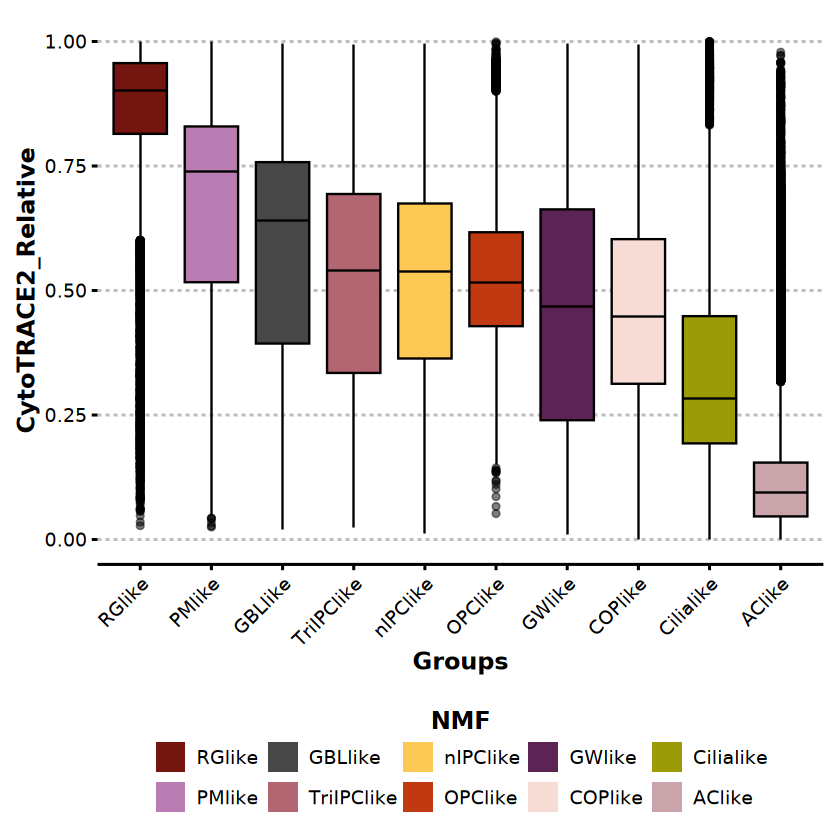

In [8]:
SCpubr::do_BoxPlot(sample = cytotrace2_result,
                   colors.use = cluster_cols,
                   group.by = 'NMF',
                        feature = "CytoTRACE2_Relative",
                        order = TRUE)

Warning message:
“Computation failed in `stat_signif()`.
Caused by error in `wilcox.test.default()`:
! not enough 'y' observations”


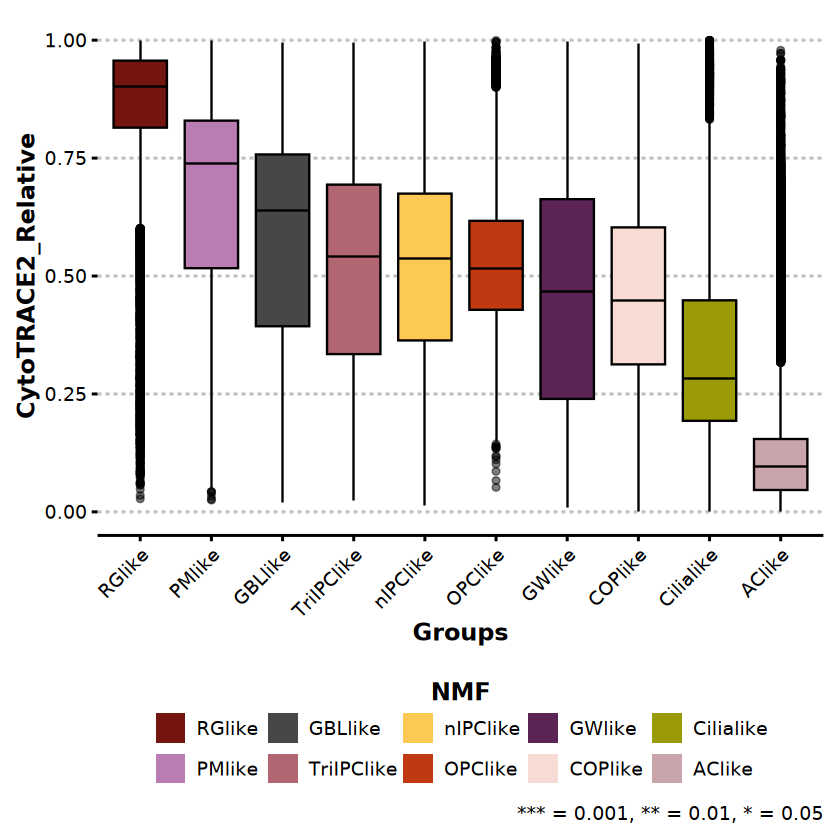

In [9]:
SCpubr::do_BoxPlot(sample = cytotrace2_result,
                   colors.use = cluster_cols,
                   group.by = 'NMF',
                        feature = "CytoTRACE2_Relative",
                        order = TRUE,
                  use_test = TRUE,
                        comparisons = list(c("PMlike", "GBlike")))

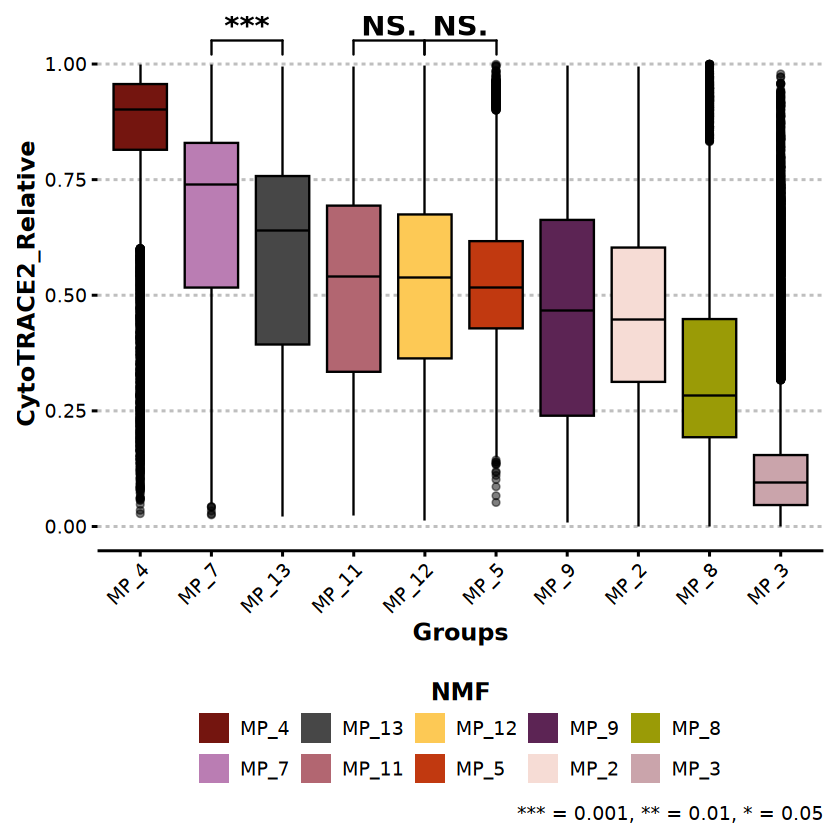

In [24]:
SCpubr::do_BoxPlot(sample = cytotrace2_result,
                   colors.use = cluster_cols,
                   group.by = 'NMF',
                        feature = "CytoTRACE2_Relative",
                        order = TRUE,
                  use_test = TRUE,
                        comparisons = list(c("MP_7", "MP_13"),
                                           c("MP_11", "MP_12"),
                                           c("MP_12", "MP_5")))

In [ ]:
saveRDS(cytotrace2_result, '/projects/0/einf2548/cruiz/dmg/data/malignant_rna_cytotrace2.rds')